# 1. Introduction

This notebook builds a binary image classifier for cats and dogs using transfer learning with a pretrained ResNet18 model from TorchVision.

The workflow is intentionally modular: dataset handling, model construction, training, evaluation, and plotting live in the `src/` package, while the notebook explains and executes the full experiment from top to bottom.


# 2. Configuration

Set paths, random seeds, device selection, and output directories. The path logic works whether Jupyter is launched from the project root or from the `notebooks/` directory.


In [1]:
from pathlib import Path
import os
import random
import sys

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
SRC_PATH = PROJECT_ROOT / "src"
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn
from torch.optim import Adam

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from dataset import (
    CLASS_NAMES,
    RAW_DATASET,
    collect_images,
    create_dataloader,
    find_invalid_images,
    get_eval_transforms,
    get_split_counts,
    get_train_transforms,
    prepare_dataset,
    set_random_seed,
    split_dataset,
)
from evaluate import (
    build_classification_report,
    build_confusion_matrix,
    evaluate_model,
    get_predictions,
    predict_image,
)
from model import (
    build_model,
    count_parameters,
    freeze_feature_extractor,
    load_checkpoint,
)
from train import train_model
from utils import (
    ensure_results_dirs,
    plot_accuracy_curve,
    plot_confusion_matrix,
    plot_loss_curve,
    plot_sample_predictions,
)

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 5
LEARNING_RATE = 1e-3

set_random_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR, PLOTS_DIR = ensure_results_dirs()
CHECKPOINT_PATH = RESULTS_DIR / "best_model.pth"

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset path : {RAW_DATASET}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Classes      : {CLASS_NAMES}")
print(f"Device       : {device}")


/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root : /home/kerollos/me/Task_AI/transfer-learning-image-classification
Dataset path : /home/kerollos/me/Task_AI/transfer-learning-image-classification/dataset/raw/PetImages
Results dir  : /home/kerollos/me/Task_AI/transfer-learning-image-classification/results
Classes      : ['Cat', 'Dog']
Device       : cpu


# 3. Dataset Exploration

Inspect the raw dataset, count valid images per class, and detect invalid files. Invalid images are reported and skipped later instead of being deleted from the raw dataset.


Valid image counts
Cat: 12,499 (50.00%)
Dog: 12,499 (50.00%)
Total valid images : 24,998
Invalid images     : 0


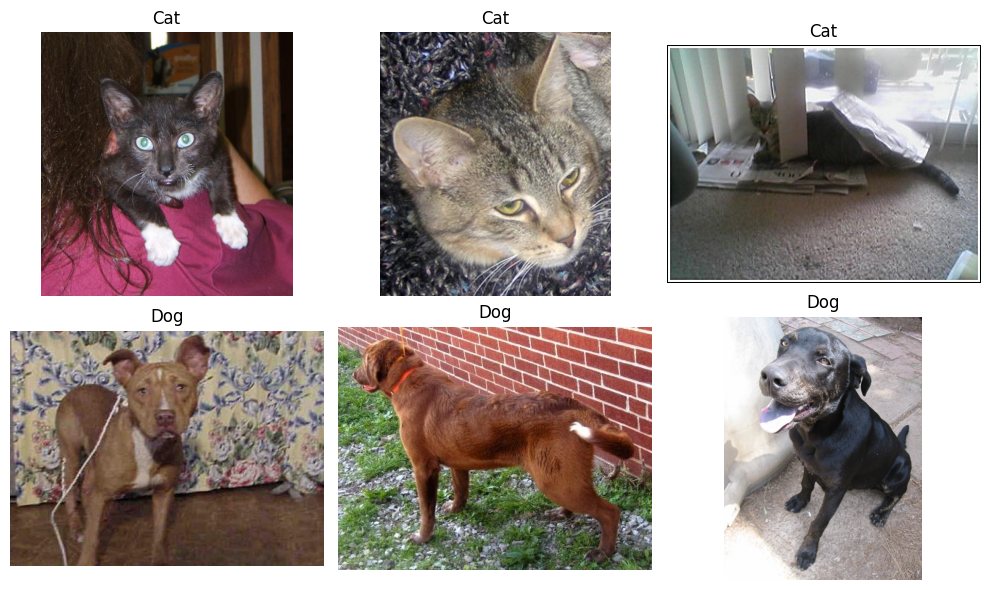

In [2]:
if not RAW_DATASET.exists():
    raise FileNotFoundError(f"Dataset directory not found: {RAW_DATASET}")

invalid_images = find_invalid_images(RAW_DATASET)
dataset = collect_images(RAW_DATASET, validate=True)
class_counts = {class_name: len(paths) for class_name, paths in dataset.items()}
total_images = sum(class_counts.values())

print("Valid image counts")
for class_name in CLASS_NAMES:
    count = class_counts[class_name]
    percentage = 100 * count / total_images if total_images else 0
    print(f"{class_name:<3}: {count:>6,} ({percentage:5.2f}%)")

print(f"Total valid images : {total_images:,}")
print(f"Invalid images     : {len(invalid_images):,}")

for image_path in invalid_images[:10]:
    print(f"Invalid: {image_path}")

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(10, 6))
for row, class_name in enumerate(CLASS_NAMES):
    sample_paths = random.sample(dataset[class_name], k=min(3, len(dataset[class_name])))
    for col, image_path in enumerate(sample_paths):
        with Image.open(image_path) as image:
            axes[row, col].imshow(image.convert("RGB"))
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


# 4. Dataset Split

Create a stratified train, validation, and test split for each class. A fixed seed keeps split membership stable across runs.


In [3]:
splits = split_dataset(dataset, seed=SEED)
split_counts = get_split_counts(splits)

for class_name in CLASS_NAMES:
    counts = split_counts[class_name]
    print(
        f"{class_name:<3} | "
        f"train: {counts['train']:>5,} | "
        f"valid: {counts['valid']:>5,} | "
        f"test: {counts['test']:>5,}"
    )

train_paths = set().union(*(set(splits[class_name]["train"]) for class_name in CLASS_NAMES))
valid_paths = set().union(*(set(splits[class_name]["valid"]) for class_name in CLASS_NAMES))
test_paths = set().union(*(set(splits[class_name]["test"]) for class_name in CLASS_NAMES))

assert train_paths.isdisjoint(valid_paths)
assert train_paths.isdisjoint(test_paths)
assert valid_paths.isdisjoint(test_paths)
print("Split overlap check passed.")


Cat | train: 8,749 | valid: 1,874 | test: 1,876
Dog | train: 8,749 | valid: 1,874 | test: 1,876
Split overlap check passed.


# 5. Data Augmentation

Training uses lightweight augmentation. Validation and test transforms stay deterministic so metrics measure model quality rather than random image changes.


In [4]:
train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

print("Training transform")
print(train_transform)
print()
print("Evaluation transform")
print(eval_transform)


Training transform
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transform
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


# 6. Dataset Preparation

Convert split file paths into PyTorch Dataset objects using the fixed class mapping `Cat -> 0` and `Dog -> 1`.


In [5]:
train_dataset = prepare_dataset(
    {class_name: splits[class_name]["train"] for class_name in CLASS_NAMES},
    transform=train_transform,
)
valid_dataset = prepare_dataset(
    {class_name: splits[class_name]["valid"] for class_name in CLASS_NAMES},
    transform=eval_transform,
)
test_dataset = prepare_dataset(
    {class_name: splits[class_name]["test"] for class_name in CLASS_NAMES},
    transform=eval_transform,
)

print(f"Train samples : {len(train_dataset):,}")
print(f"Valid samples : {len(valid_dataset):,}")
print(f"Test samples  : {len(test_dataset):,}")
print(f"Class mapping : {dict(enumerate(CLASS_NAMES))}")


Train samples : 17,498
Valid samples : 3,748
Test samples  : 3,752
Class mapping : {0: 'Cat', 1: 'Dog'}


# 7. DataLoaders

Build DataLoaders for mini-batch training and evaluation.


In [6]:
train_loader = create_dataloader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)
valid_loader = create_dataloader(
    valid_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)
test_loader = create_dataloader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)

images, labels = next(iter(train_loader))
print(f"Train batches : {len(train_loader):,}")
print(f"Valid batches : {len(valid_loader):,}")
print(f"Test batches  : {len(test_loader):,}")
print(f"Image batch   : {tuple(images.shape)}")
print(f"Label batch   : {tuple(labels.shape)}")


Train batches : 547
Valid batches : 118
Test batches  : 118
Image batch   : (32, 3, 224, 224)
Label batch   : (32,)


# 8. Build Model

Load a pretrained ResNet18 model and replace its classifier head for two output classes.


In [7]:
model = build_model(num_classes=len(CLASS_NAMES), pretrained=True)
print(model.fc)
print(f"Output classes: {model.fc.out_features}")


Linear(in_features=512, out_features=2, bias=True)
Output classes: 2


# 9. Freeze Feature Extractor

Freeze the pretrained backbone and train only the final classifier layer. This stabilizes transfer learning and avoids the test-accuracy collapse that can happen when the full backbone is updated aggressively on a small task.


In [8]:
model = freeze_feature_extractor(model)
parameter_counts = count_parameters(model)

print(f"Total parameters     : {parameter_counts['total']:,}")
print(f"Trainable parameters : {parameter_counts['trainable']:,}")


Total parameters     : 11,177,538
Trainable parameters : 1,026


# 10. Training Configuration

Define the loss function, optimizer, epoch count, and checkpoint location. The optimizer receives only trainable parameters.


In [9]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(
    (parameter for parameter in model.parameters() if parameter.requires_grad),
    lr=LEARNING_RATE,
)

print(f"Epochs          : {EPOCHS}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Checkpoint path : {CHECKPOINT_PATH}")


Epochs          : 5
Learning rate   : 0.001
Checkpoint path : /home/kerollos/me/Task_AI/transfer-learning-image-classification/results/best_model.pth


# 11. Train Model

Train the classifier head and save the best validation checkpoint automatically.


In [10]:
history = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
)

print(f"Best epoch      : {int(history['best_epoch'][0])}")
print(f"Best valid acc  : {history['best_valid_acc'][0]:.4f}")


Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Training:  20%|██        | 1/5 [04:59<19:56, 299.12s/it]

Epoch [1/5] | Train Loss: 0.1344 | Train Acc: 0.9494 | Valid Loss: 0.0697 | Valid Acc: 0.9725


Training:  40%|████      | 2/5 [09:46<14:36, 292.17s/it]

Epoch [2/5] | Train Loss: 0.1029 | Train Acc: 0.9595 | Valid Loss: 0.0620 | Valid Acc: 0.9773


Training:  60%|██████    | 3/5 [14:43<09:48, 294.37s/it]

Epoch [3/5] | Train Loss: 0.0995 | Train Acc: 0.9604 | Valid Loss: 0.0585 | Valid Acc: 0.9776


Training:  80%|████████  | 4/5 [19:26<04:50, 290.07s/it]

Epoch [4/5] | Train Loss: 0.0915 | Train Acc: 0.9632 | Valid Loss: 0.0586 | Valid Acc: 0.9784


Training: 100%|██████████| 5/5 [24:25<00:00, 293.14s/it]

Epoch [5/5] | Train Loss: 0.0896 | Train Acc: 0.9633 | Valid Loss: 0.0579 | Valid Acc: 0.9763
Best epoch      : 4
Best valid acc  : 0.9784


# 12. Evaluate Model

Evaluate the best in-memory model on train, validation, and test splits. Large train/validation accuracy with poor test accuracy usually indicates split, label, transform, or notebook-state bugs; these checks use the same label mapping and deterministic evaluation transform for all evaluation splits.


In [11]:
train_eval_loss, train_eval_acc = evaluate_model(model, train_loader, criterion, device)
valid_eval_loss, valid_eval_acc = evaluate_model(model, valid_loader, criterion, device)
test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

test_labels, test_predictions, test_probabilities = get_predictions(model, test_loader, device)

print(f"Train Loss: {train_eval_loss:.4f} | Train Acc: {train_eval_acc:.4f}")
print(f"Valid Loss: {valid_eval_loss:.4f} | Valid Acc: {valid_eval_acc:.4f}")
print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
print()
print("Classification report")
print(build_classification_report(test_labels, test_predictions))


Train Loss: 0.0643 | Train Acc: 0.9739
Valid Loss: 0.0586 | Valid Acc: 0.9784
Test  Loss: 0.0627 | Test  Acc: 0.9765

Classification report
              precision    recall  f1-score   support

         Cat       0.96      0.99      0.98      1876
         Dog       0.99      0.96      0.98      1876

    accuracy                           0.98      3752
   macro avg       0.98      0.98      0.98      3752
weighted avg       0.98      0.98      0.98      3752



# 13. Plot Training History

Save separate loss and accuracy curves under `results/plots/`.


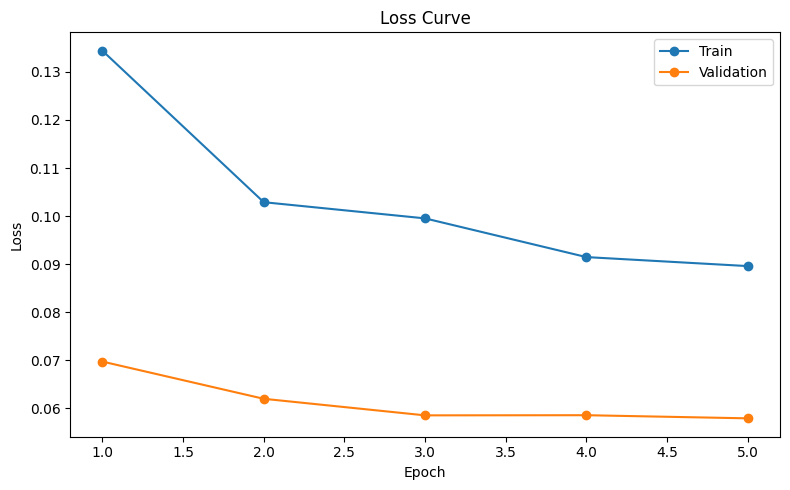

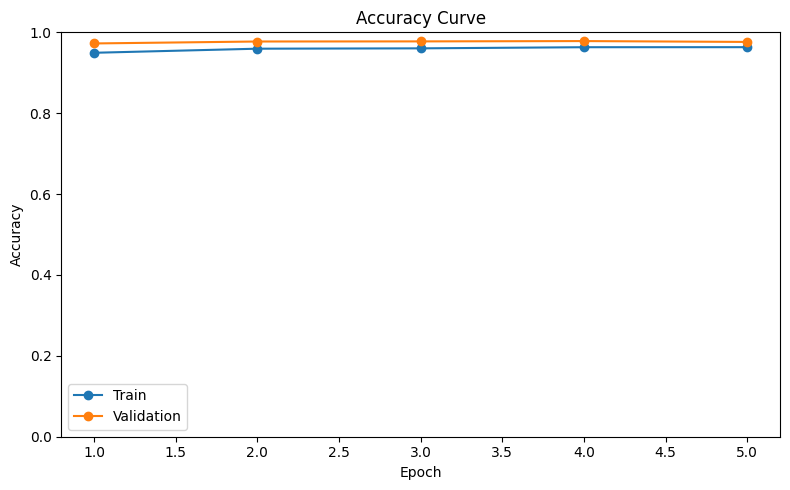

Saved: /home/kerollos/me/Task_AI/transfer-learning-image-classification/results/plots/loss_curve.png
Saved: /home/kerollos/me/Task_AI/transfer-learning-image-classification/results/plots/accuracy_curve.png


In [12]:
loss_curve_path = PLOTS_DIR / "loss_curve.png"
accuracy_curve_path = PLOTS_DIR / "accuracy_curve.png"

plot_loss_curve(history, loss_curve_path)
plot_accuracy_curve(history, accuracy_curve_path)

print(f"Saved: {loss_curve_path}")
print(f"Saved: {accuracy_curve_path}")


# 14. Predict Custom Images

Run single-image prediction. If no separate custom image folder exists, use a few held-out test images as a reproducible demonstration.


In [13]:
CUSTOM_IMAGE_DIR = PROJECT_ROOT / "dataset" / "custom"

if CUSTOM_IMAGE_DIR.exists():
    custom_image_paths = sorted(
        path for path in CUSTOM_IMAGE_DIR.iterdir()
        if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )
else:
    custom_image_paths = test_dataset.image_paths[:6]

for image_path in custom_image_paths[:6]:
    predicted_class, confidence = predict_image(
        model=model,
        image_path=image_path,
        transform=eval_transform,
        device=device,
    )
    print(f"{image_path.name:<24} -> {predicted_class:<3} ({confidence:.3f})")


6708.jpg                 -> Cat (1.000)
9831.jpg                 -> Cat (0.990)
11489.jpg                -> Cat (0.995)
3109.jpg                 -> Cat (1.000)
11134.jpg                -> Cat (1.000)
12281.jpg                -> Cat (0.999)


# 15. Visualize Predictions

Save a grid of sample test predictions to `results/plots/sample_predictions.png`.


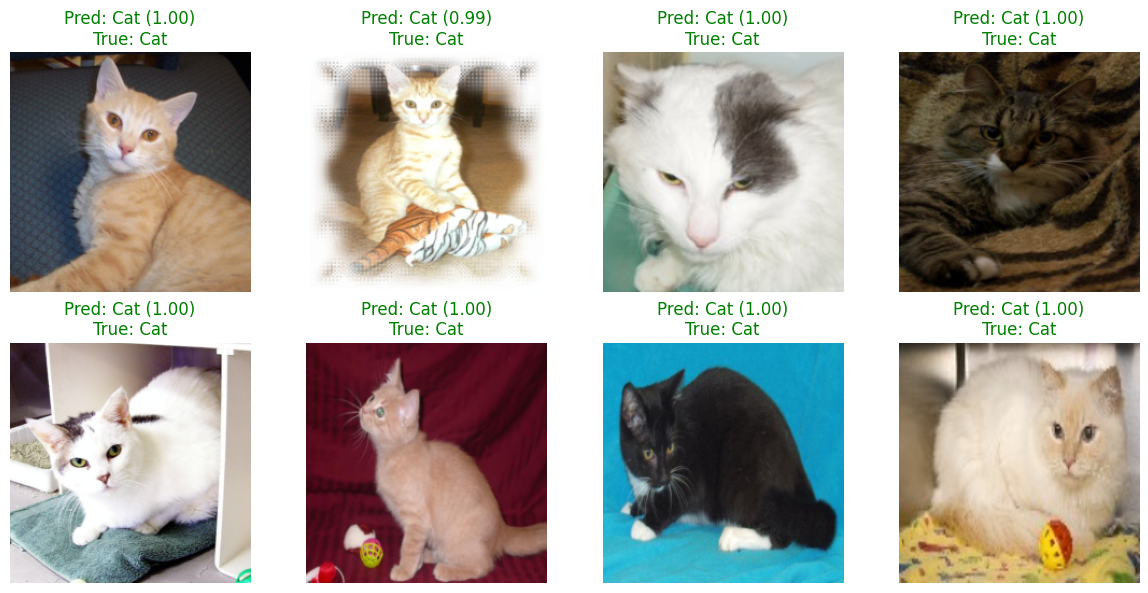

Saved: /home/kerollos/me/Task_AI/transfer-learning-image-classification/results/plots/sample_predictions.png


In [14]:
sample_images, sample_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    sample_outputs = model(sample_images.to(device))
    sample_probabilities = torch.softmax(sample_outputs, dim=1).cpu().numpy()
    sample_predictions = sample_probabilities.argmax(axis=1)

sample_predictions_path = PLOTS_DIR / "sample_predictions.png"
plot_sample_predictions(
    images=sample_images,
    labels=sample_labels,
    predictions=sample_predictions,
    probabilities=sample_probabilities,
    save_path=sample_predictions_path,
    class_names=CLASS_NAMES,
)
print(f"Saved: {sample_predictions_path}")


# 16. Save Best Model

The training loop saves the best validation checkpoint automatically. This section verifies the artifact before loading it in a fresh model instance.


In [15]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Expected checkpoint was not created: {CHECKPOINT_PATH}")

checkpoint_size_mb = CHECKPOINT_PATH.stat().st_size / (1024 * 1024)
print(f"Best model checkpoint: {CHECKPOINT_PATH}")
print(f"File size            : {checkpoint_size_mb:.2f} MB")


Best model checkpoint: /home/kerollos/me/Task_AI/transfer-learning-image-classification/results/best_model.pth
File size            : 42.71 MB


# 17. Load Saved Model

Create a new ResNet18 instance, apply the same freeze configuration, and load the saved best weights.


In [16]:
loaded_model = build_model(num_classes=len(CLASS_NAMES), pretrained=True)
loaded_model = freeze_feature_extractor(loaded_model)
loaded_model = loaded_model.to(device)
checkpoint_metadata = load_checkpoint(loaded_model, CHECKPOINT_PATH, device)

print("Checkpoint metadata")
print(checkpoint_metadata)


Checkpoint metadata
{'epoch': 4, 'valid_accuracy': 0.9783884738527214}


# 18. Final Evaluation

Evaluate the reloaded best model and save the confusion matrix. This final metric is the one to report because it verifies the saved artifact, not just the in-memory model state.


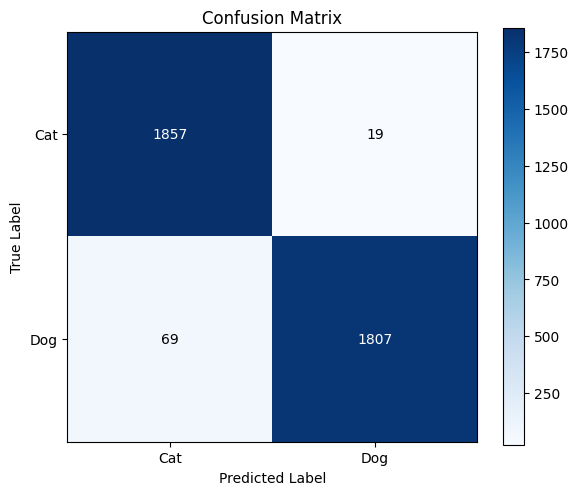

Final Test Loss: 0.0627
Final Test Acc : 0.9765

Final classification report
              precision    recall  f1-score   support

         Cat       0.96      0.99      0.98      1876
         Dog       0.99      0.96      0.98      1876

    accuracy                           0.98      3752
   macro avg       0.98      0.98      0.98      3752
weighted avg       0.98      0.98      0.98      3752

Saved: /home/kerollos/me/Task_AI/transfer-learning-image-classification/results/plots/confusion_matrix.png


In [17]:
final_test_loss, final_test_acc = evaluate_model(
    loaded_model,
    test_loader,
    criterion,
    device,
)
final_labels, final_predictions, final_probabilities = get_predictions(
    loaded_model,
    test_loader,
    device,
)
confusion = build_confusion_matrix(final_labels, final_predictions)
confusion_matrix_path = PLOTS_DIR / "confusion_matrix.png"
plot_confusion_matrix(confusion, confusion_matrix_path, CLASS_NAMES)

print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Acc : {final_test_acc:.4f}")
print()
print("Final classification report")
print(build_classification_report(final_labels, final_predictions))
print(f"Saved: {confusion_matrix_path}")
